In [ ]:
!gdown --id 1wgnlEXahfvYiD6elHor7AwWQazO59Ssg
!gdown --id 1hFKdcLMoF7zhyIfRmU8fXfZRZ8RFkTsM

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1wgnlEXahfvYiD6elHor7AwWQazO59Ssg
From (redirected): https://drive.google.com/uc?id=1wgnlEXahfvYiD6elHor7AwWQazO59Ssg&confirm=t&uuid=f7040168-e0c3-4ff2-b634-6c48a2c41683
To: /content/Egyptian_YOLO_20K.zip
100% 5.98G/5.98G [01:10<00:00, 85.3MB/s]
/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1hFKdcLMoF7zhyIfRmU8fXfZRZ8RFkTsM
From (redirected): https://drive.google.com/uc?id=1hFKdcLMoF7zhyIfRmU8fXfZRZ8RFkTsM&confirm=t&uuid=c8569d1e-d9bd-450b-8ed7-8eb3f40c68d3
To: /content/Cha

In [ ]:
!unzip -q Egyptian_YOLO_20K.zip
!unzip -q CharsMerged.zip

In [ ]:
!mv /content/content/CharDataset_Merged /content/
!rm -r content

In [ ]:
!pip install ultralytics -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 39.1 MB/s eta 0:00:00


In [ ]:
from ultralytics import YOLO

model = YOLO("yolo26n.pt")

train_params = {
            "data": "/content/Egyptian_YOLO_Dataset/data.yaml",
            "epochs": 20,
            "batch": 16,
            "imgsz": 640,
            "optimizer": "AdamW",
            "device": 0,
            "workers": 8,
            "seed": 46,
            "amp": True,
            "patience": 4,
            "cos_lr": True,
            "augment": True,
            "hsv_h": 0.7,
            "hsv_s": 0.45,
            "hsv_v": 0.45,
            "degrees": 10,
            "translate": 0.0,
            "scale": 0.15,
            "shear": 0.0,
            "perspective": 0.001,
            "flipud": 0.0,
            "fliplr": 0.0,
            "mosaic": 0.5,
            "mixup": 0.0,
            "copy_paste": 0.0,
            "close_mosaic": 1,
        }

model.train(**train_params)


Ultralytics 8.4.7 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=1, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/Egyptian_YOLO_Dataset/data.yaml, degrees=10, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.0, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.7, hsv_s=0.45, hsv_v=0.45, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt, momentum=0.937, mosaic=0.5, multi_scale=0.0, name=train2, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_mask=True, patience=4, perspective=0.001, plot

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7aef749e5790>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

## Chars Detection

In [ ]:
from ultralytics import YOLO, RTDETR

model = YOLO("yolo12n.pt")  # or yolov8s.pt for better accuracy


train_params = {
            "data": "/content/CharDataset_Merged/data.yaml",
            "epochs": 20,
            "batch": 16,
            "imgsz": 480,
            "optimizer": "AdamW",
            "device": 0,
            "workers": 8,
            "seed": 46,
            "amp": True,
            "patience": 10,
            "cos_lr": True,
            "augment": True,
            "hsv_h": 0.7,
            "hsv_s": 1.0,
            "hsv_v": 1.0,
            "degrees": 5,
            "translate": 0.0,
            "scale": 0.3,
            "shear": 0.05,
            "perspective": 0.001,
            "flipud": 0.0,
            "fliplr": 0.0,
            "mosaic": 0.7,
            "mixup": 0.0,
            "copy_paste": 0.0,
            "close_mosaic": 5,
            "nms": True
        }

model.train(**train_params)


Ultralytics 8.4.7 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=5, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/CharDataset_Merged/data.yaml, degrees=5, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.0, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.7, hsv_s=1.0, hsv_v=1.0, imgsz=480, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo12n.pt, momentum=0.937, mosaic=0.7, multi_scale=0.0, name=train4, nbs=64, nms=True, opset=None, optimize=False, optimizer=AdamW, overlap_mask=True, patience=10, perspective=0.001, plots=True

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7aef85da8b60>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,  

In [ ]:
from ultralytics import YOLO, RTDETR

model = YOLO("yolo12n.pt")  # or yolov8s.pt for better accuracy


train_params = {
            "data": "/content/CharDataset_Merged/data.yaml",
            "epochs": 20,
            "batch": 16,
            "imgsz": 480,
            "optimizer": "AdamW",
            "device": 0,
            "workers": 8,
            "seed": 46,
            "amp": True,
            "patience": 10,
            "cos_lr": True,
            "augment": True,
            "hsv_h": 0.7,
            "hsv_s": 1.0,
            "hsv_v": 1.0,
            "degrees": 5,
            "translate": 0.0,
            "scale": 0.3,
            "shear": 0.1,
            "perspective": 0.001,
            "flipud": 0.0,
            "fliplr": 0.0,
            "mosaic": 0.7,
            "mixup": 0.0,
            "copy_paste": 0.0,
            "close_mosaic": 5,
            "nms": True
        }

model.train(**train_params)


Ultralytics 8.4.7 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=5, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/CharDataset_Merged/data.yaml, degrees=5, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.0, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.7, hsv_s=1.0, hsv_v=1.0, imgsz=480, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo12n.pt, momentum=0.937, mosaic=0.7, multi_scale=0.0, name=train5, nbs=64, nms=True, opset=None, optimize=False, optimizer=AdamW, overlap_mask=True, patience=10, perspective=0.001, plots=True

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7aef76537fb0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,  

In [ ]:
!wget -O /content/NotoNaskhArabic-Regular.ttf \
https://github.com/googlefonts/noto-fonts/raw/main/hinted/ttf/NotoNaskhArabic/NotoNaskhArabic-Regular.ttf

--2026-01-23 23:04:57--  https://github.com/googlefonts/noto-fonts/raw/main/hinted/ttf/NotoNaskhArabic/NotoNaskhArabic-Regular.ttf
Resolving github.com (github.com)... 140.82.121.4
Connecting to github.com (github.com)|140.82.121.4|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://github.com/notofonts/noto-fonts/raw/main/hinted/ttf/NotoNaskhArabic/NotoNaskhArabic-Regular.ttf [following]
--2026-01-23 23:04:57--  https://github.com/notofonts/noto-fonts/raw/main/hinted/ttf/NotoNaskhArabic/NotoNaskhArabic-Regular.ttf
Reusing existing connection to github.com:443.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/notofonts/noto-fonts/main/hinted/ttf/NotoNaskhArabic/NotoNaskhArabic-Regular.ttf [following]
--2026-01-23 23:04:57--  https://raw.githubusercontent.com/notofonts/noto-fonts/main/hinted/ttf/NotoNaskhArabic/NotoNaskhArabic-Regular.ttf
Resolving raw.githubusercontent.com (raw.githubusercontent

In [ ]:
!pip install arabic_reshaper  python-bidi

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 300.6/300.6 kB 12.4 MB/s eta 0:00:00



0: 448x640 1 license_plate, 13.0ms
Speed: 3.0ms preprocess, 13.0ms inference, 0.4ms postprocess per image at shape (1, 3, 448, 640)

0: 288x480 1 1, 1 6, 1 9, 1 ر, 1 ف, 1 ھ, 12.8ms
Speed: 0.9ms preprocess, 12.8ms inference, 1.2ms postprocess per image at shape (1, 3, 288, 480)

0: 512x640 2 license_plates, 11.1ms
Speed: 3.0ms preprocess, 11.1ms inference, 0.4ms postprocess per image at shape (1, 3, 512, 640)

0: 384x480 1 1, 1 4, 1 5, 1 7, 1 ج, 1 د, 1 ط, 13.8ms
Speed: 2.0ms preprocess, 13.8ms inference, 1.2ms postprocess per image at shape (1, 3, 384, 480)

0: 288x480 (no detections), 13.5ms
Speed: 1.4ms preprocess, 13.5ms inference, 0.5ms postprocess per image at shape (1, 3, 288, 480)

0: 544x640 2 license_plates, 11.1ms
Speed: 3.5ms preprocess, 11.1ms inference, 0.4ms postprocess per image at shape (1, 3, 544, 640)

0: 256x480 1 7, 1 8, 1 9, 1 م, 1 ھ, 1 ي, 13.7ms
Speed: 1.6ms preprocess, 13.7ms inference, 1.2ms postprocess per image at shape (1, 3, 256, 480)

0: 288x480 1 1, 1 2, 1

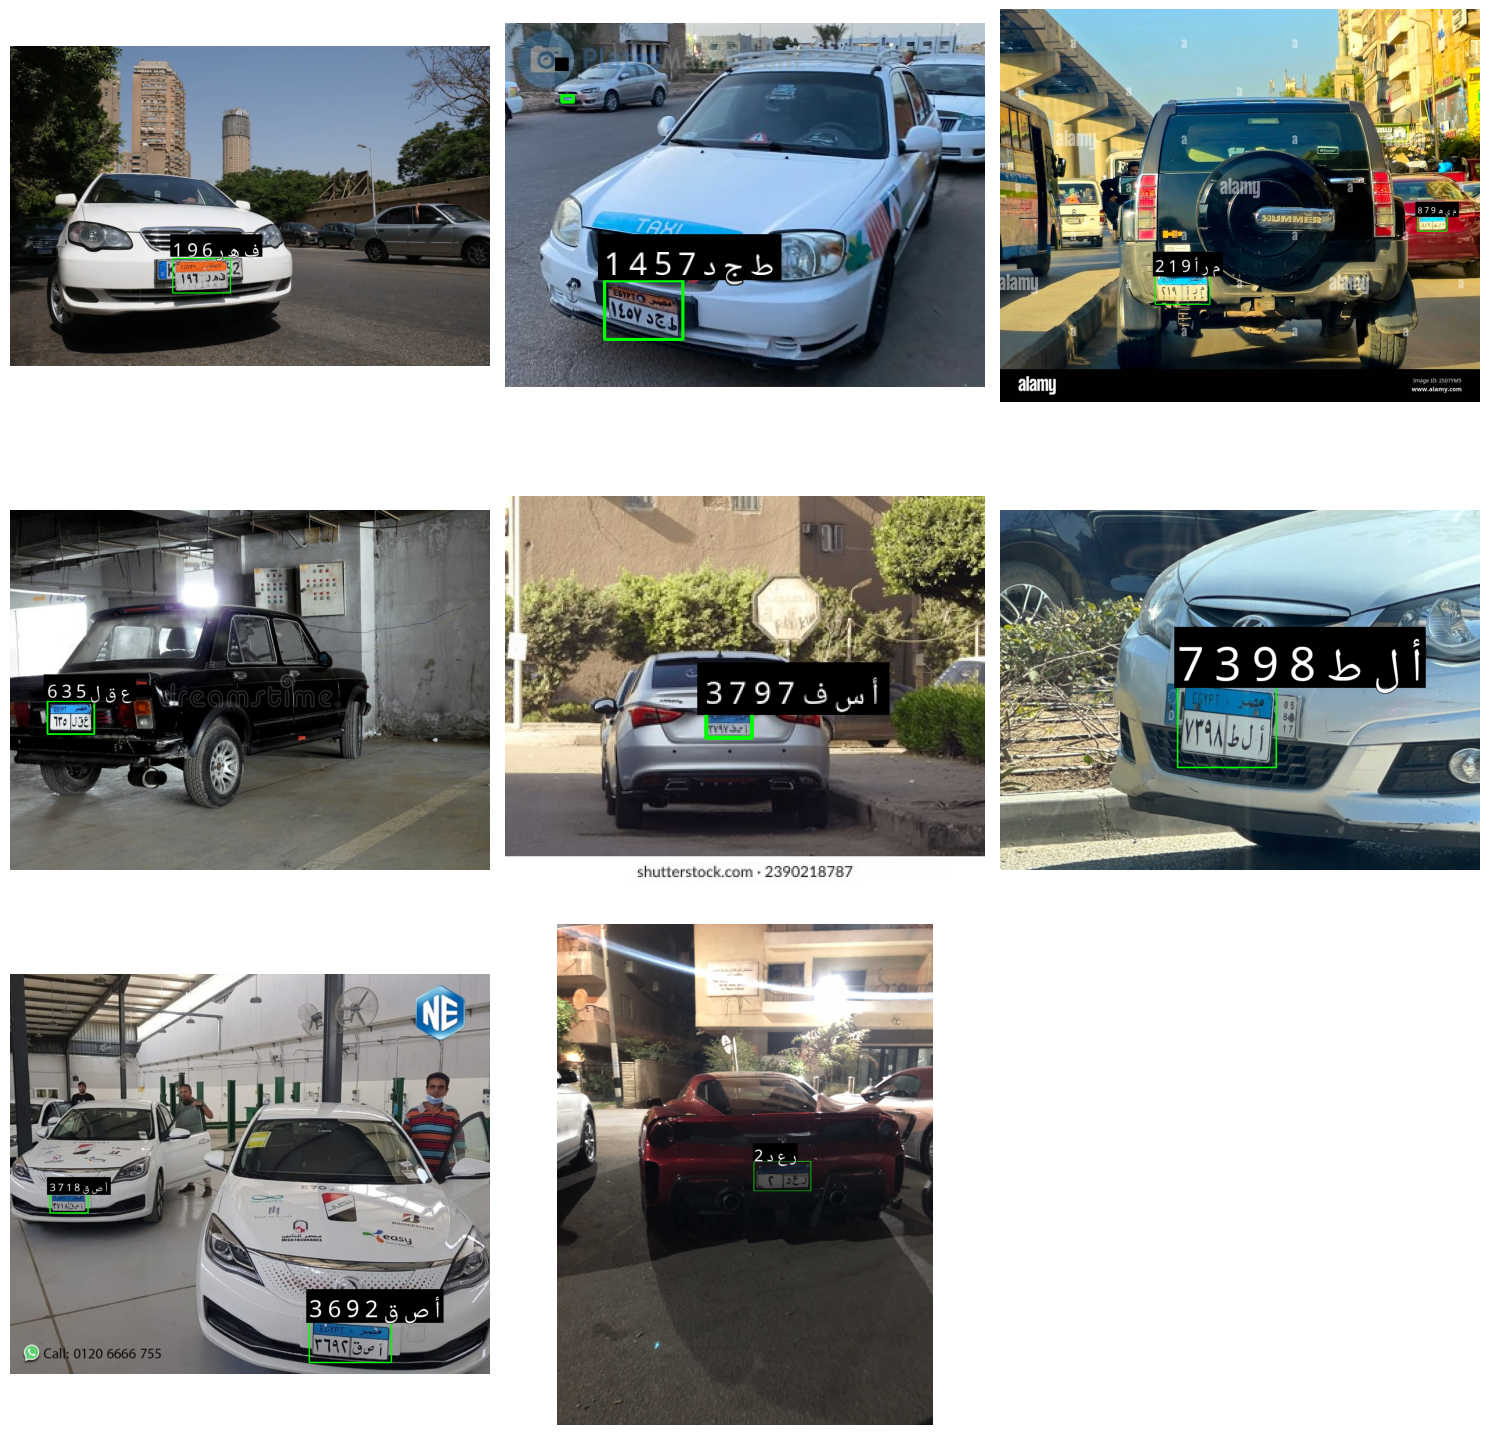

In [ ]:
from ultralytics import YOLO
import cv2
import numpy as np
import os
import math
import matplotlib.pyplot as plt

from PIL import Image, ImageDraw, ImageFont
import arabic_reshaper
from bidi.algorithm import get_display

FONT_PATH = "/content/NotoNaskhArabic-Regular.ttf"

def draw_arabic_text(
    img,
    text,
    position,
    font_size,
    text_color=(255, 255, 255),
    bg_color=(0, 0, 0),
    outline_color=(0, 0, 0)
):
    reshaped_text = arabic_reshaper.reshape(text)
    bidi_text = get_display(reshaped_text)

    pil_img = Image.fromarray(img)
    draw = ImageDraw.Draw(pil_img)
    font = ImageFont.truetype(FONT_PATH, font_size)

    x, y = position
    bbox = draw.textbbox((0, 0), bidi_text, font=font)
    w = bbox[2] - bbox[0]
    h = bbox[3] - bbox[1]

    padding = 6

    draw.rectangle(
        [x - padding, y - padding, x + w + padding, y + h + padding],
        fill=bg_color
    )

    for dx in [-1, 0, 1]:
        for dy in [-1, 0, 1]:
            draw.text((x + dx, y + dy), bidi_text, font=font, fill=outline_color)

    draw.text((x, y), bidi_text, font=font, fill=text_color)

    return np.array(pil_img)

plate_model = YOLO('/content/runs/detect/train2/weights/best.pt')
char_model  = YOLO('/content/runs/detect/train4/weights/best.pt')

IMAGE_DIR = "/content/images"
processed_images = []

for img_name in sorted(os.listdir(IMAGE_DIR)):

    if not img_name.lower().endswith((".jpg", ".png", ".jpeg", "webp")):
        continue

    img_path = os.path.join(IMAGE_DIR, img_name)
    img = cv2.imread(img_path)
    if img is None:
        continue

    plate_results = plate_model(img)[0]

    for plate_box in plate_results.boxes:
        x1, y1, x2, y2 = map(int, plate_box.xyxy[0])

        plate_crop = img[y1:y2, x1:x2]
        if plate_crop.size == 0:
            continue

        char_results = char_model(plate_crop, nms=True)[0]
        if char_results.boxes is None:
            continue

        # ===== SORT LEFT → RIGHT =====
        chars = sorted(
            char_results.boxes,
            key=lambda b: b.xyxy[0][0]
        )

        # ===== SEPARATE CHARACTERS WITH SPACES =====
        plate_text = " ".join(
            [char_model.names[int(b.cls[0])] for b in chars]
        )

        # ===== DRAW PLATE BOX =====
        cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)

        # ===== AUTO FONT SIZE =====
        plate_height = y2 - y1
        font_size = max(22, int(plate_height * 0.55))

        text_x = x1
        text_y = y1 - font_size - 8 if y1 > font_size + 10 else y2 + 5

        img = draw_arabic_text(
            img,
            plate_text,
            (text_x, text_y),
            font_size,
            text_color=(255, 255, 255),
            bg_color=(0, 0, 0),
            outline_color=(0, 0, 0)
        )

    processed_images.append(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))

cols = 3
rows = math.ceil(len(processed_images) / cols)

plt.figure(figsize=(15, 5 * rows))

for i, img in enumerate(processed_images):
    plt.subplot(rows, cols, i + 1)
    plt.imshow(img)
    plt.axis("off")

plt.tight_layout()
plt.show()


In [ ]:
!wget -P /content/images "https://i.redd.it/zf9f5v9t9my61.jpg"

--2026-01-24 00:10:16--  https://i.redd.it/zf9f5v9t9my61.jpg
Resolving i.redd.it (i.redd.it)... 151.101.1.140, 151.101.65.140, 151.101.129.140, ...
Connecting to i.redd.it (i.redd.it)|151.101.1.140|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1070774 (1.0M) [image/jpeg]
Saving to: ‘/content/images/zf9f5v9t9my61.jpg’

zf9f5v9t9my61.jpg   100%[===================>]   1.02M  --.-KB/s    in 0.02s   

2026-01-24 00:10:16 (47.8 MB/s) - ‘/content/images/zf9f5v9t9my61.jpg’ saved [1070774/1070774]

